In [ ]:


#Пути данных
DATA_PATH = 'data'
CLASSIFICATION_PATH = os.path.join(DATA_PATH, 'Classification')
DETECTION_PATH = os.path.join(DATA_PATH, 'Detection')

#Список изображений
images_list = os.listdir(os.path.join(CLASSIFICATION_PATH, 'JPEGImages'))

#Файл дополнительной разметки в формате словаря
with open(os.path.join('data', 'acne04v2-main', 'Acne04-v2_annotations.json'), 'r') as file:
    y_file = yaml.safe_load(file)
    print(type(y_file))

#Датафрейм с дополнительной разметкой 
df = pd.DataFrame(y_file['annotations'])
df_images = pd.DataFrame(y_file['images'])
# Фильтрация от ненужных меток 
idx = 0
num_add = 0
threshhold = 0.5

#Создание набора данных после фильтрации
df_end = pd.DataFrame(columns=df.columns)
for num in range(len(pd.unique(df['image_id']))):
    print(f'Работа с изображением {num}')
    img = Image.open(os.path.join(CLASSIFICATION_PATH, 'JPEGImages', df_images[df_images['id'] == num]['file_name'].values[0])).convert('RGB')
    img_arr = np.array(img)
    H, W, C = img_arr.shape
    mask_arr = np.zeros((H, W, C))

    annot_dict = {}
    image = y_file['images'][num]['file_name']
    name, _ = image.split('.')
    tree = ET.parse(os.path.join(DETECTION_PATH, 'VOC2007', 'Annotations', f'{name}.xml'))
    root = tree.getroot()
    objects = {}
    for i, item in enumerate(root):
        if item.find('bndbox') != None:
            xmin = item.find('bndbox/xmin').text
            ymin = item.find('bndbox/ymin').text
            xmax = item.find('bndbox/xmax').text
            ymax = item.find('bndbox/ymax').text
            objects[i] = [xmin, ymin, xmax, ymax]

    annot_dict[name] = objects
    
    for item in annot_dict:
        for obj in annot_dict[item]:
            cv.rectangle(mask_arr, (int(annot_dict[item][obj][0]), int(annot_dict[item][obj][3])), (int(annot_dict[item][obj][2]), int(annot_dict[item][obj][1])), (255, 255, 255), -1)
    L = len(df[df['image_id'] == num]) + idx
    for n in range(idx, L):
        #print(n, num, L)
        radius = df['radius'][n]
        coords = df['coordinates'][n]
        xmin = int(coords[0] - radius)
        xmax = int(coords[0] + radius)
        ymin = int(coords[1] - radius)
        ymax = int(coords[1] + radius)
        roi = mask_arr[ymin:ymax, xmin:xmax, :]
        total_size = (ymax - ymin) * (xmax - xmin)
        orig_size = 0
        H, W, _ = roi.shape
        for y in range(H):
            for x in range(W):
                if (roi[y][x][0] == 255) and (roi[y][x][2] == 255) and (roi[y][x][1] == 255):
                    orig_size+=1
        #print(f'Площадь перекрытия объекта равна: {orig_size / total_size:.4f}')
        if orig_size / total_size <= threshhold:
            df_end.loc[num_add] = df.loc[n].copy()
            num_add+=1
    #print(num_add, idx, n)
    idx+=len(df[df['image_id'] == num])
    print(f'Было добавлено:{num_add} из {L}')

#Создание первого csv файла с данными о изображениях
col_list = ['id_images', 'filename', 'height', 'width']
df_images = pd.DataFrame(columns=col_list)
if not os.path.exists('data/csvs'):
    os.mkdir('data/csvs')
for i, image in enumerate(images_list):
    img = Image.open(os.path.join(CLASSIFICATION_PATH, 'JPEGImages', image)).convert('RGB')
    img_arr = np.array(img)
    H, W, _ = img_arr.shape
    df_images.loc[i] = pd.Series([i, image, H, W], index = df_images.columns)

#Создание первого датафрейма из оригинальной разметки
annot_columns = ['id_images', 'xmin', 'xmax', 'ymin', 'ymax', 'annot_V']
df_v1 = pd.DataFrame(columns=annot_columns)
counter = 0
for image in images_list:
    num = df_images[df_images['filename'] == image]['id_images']
    H = df_images[df_images['filename'] == image]['height']
    W = df_images[df_images['filename'] == image]['width']
    name, _ = image.split('.')
    tree = ET.parse(os.path.join(DETECTION_PATH, 'VOC2007', 'Annotations', f'{name}.xml'))
    root = tree.getroot()
    columns = ['xmin', 'ymin', 'xmax', 'ymax']
    for item in root:
        if item.find('bndbox') != None:
            xmin = float(item.find('bndbox/xmin').text) 
            ymin = float(item.find('bndbox/ymin').text) 
            xmax = float(item.find('bndbox/xmax').text) 
            ymax = float(item.find('bndbox/ymax').text) 
            df_v1.loc[counter] = pd.Series([num.values[0], xmin, xmax, ymin, ymax, 'V1'], index = df_v1.columns)
            counter+=1

#Создание второго датафрейма из дополнительной разметки
df_images_v2 = pd.DataFrame(y_file['images'])
df_end = df_end.drop('class_name', axis = 1)
df_end = df_end.drop('id', axis = 1)
df_v2 = pd.DataFrame(columns=annot_columns)
c = len(df_v1)
for name in df_images['filename']:
    id = df_images_v2[df_images_v2['file_name'] == name]['id']
    id_v1 = df_images[df_images['filename'] == name]['id_images']

    if id.values.size != 0:
        id = id.values[0]
        id_v1 = id_v1.values[0]
        fragment = df_end[df_end['image_id'] == id]
        H = df_images[df_images['id_images'] == id]['height'].values[0]
        W = df_images[df_images['id_images'] == id]['width'].values[0]
        for n in range(len(fragment)):
            row = fragment.iloc[n]
            radius = row['radius']
            coords = row['coordinates']
            xmin = float(coords[0] - radius) 
            xmax = float(coords[0] + radius) 
            ymin = float(coords[1] - radius) 
            ymax = float(coords[1] + radius) 
            df_v2.loc[c] = pd.Series([id_v1, xmin, xmax, ymin, ymax, 'V2'], index = df_v2.columns)
            c+=1

#Слияние двух датафреймов в один и фильтрация от больших и отрицательных значений координат  
df_FINAL = pd.concat((df_v1, df_v2))
df_FINAL = df_FINAL[(df_FINAL['xmax'] < 7000) & (df_FINAL['xmin'] > 0)]
df_sorted = df_FINAL.sort_values(by = 'id_images', )


KeyboardInterrupt: 

In [ ]:
df_merged = df_sorted.merge(df_images[['id_images', 'height', 'width']], 
                            on='id_images', 
                            how='left')

# 2. Проверяем, что все объекты получили размеры
if df_merged['width'].isna().sum() > 0:
    print(f"Внимание: {df_merged['width'].isna().sum()} объектов без информации о размере!")
    df_merged = df_merged.dropna(subset=['width', 'height'])

# 3. Нормализуем координаты (каждая строка использует свои width/height)
df_merged['x_center'] = ((df_merged['xmin'] + df_merged['xmax']) / 2) / df_merged['width']
df_merged['y_center'] = ((df_merged['ymin'] + df_merged['ymax']) / 2) / df_merged['height']
df_merged['width_norm'] = (df_merged['xmax'] - df_merged['xmin']) / df_merged['width']
df_merged['height_norm'] = (df_merged['ymax'] - df_merged['ymin']) / df_merged['height']

# 4. Обрезаем до [0, 1] на случай выхода за границы
df_merged['x_center'] = df_merged['x_center'].clip(0, 1)
df_merged['y_center'] = df_merged['y_center'].clip(0, 1)
df_merged['width_norm'] = df_merged['width_norm'].clip(0, 1)
df_merged['height_norm'] = df_merged['height_norm'].clip(0, 1)

In [2]:
df_annot = pd.read_csv('data/Annotations/patches.csv')

In [3]:
df_annot

,Unnamed: 0,filename,images_id,patch_id,x_center,y_center,width,height,class_id
0,0,levle0_1-0.jpg,1,0,0.578406,0.913628,0.035347,0.031829,0
1,1,levle0_1-0.jpg,1,0,0.352667,0.988860,0.024100,0.021701,0
2,2,levle0_1-0.jpg,1,0,0.913400,0.579427,0.024100,0.021701,0
3,3,levle0_1-0.jpg,1,0,0.356282,0.722295,0.079531,0.094763,0
4,4,levle0_1-1.jpg,1,1,0.078406,0.913628,0.035347,0.031829,0
...,...,...,...,...,...,...,...,...,...
99407,99407,levle3_97-26.jpg,1456,26,0.283082,0.647672,0.072272,0.234069,0
99408,99408,levle3_97-26.jpg,1456,26,0.384619,0.734681,0.089068,0.162990,0
99409,99409,levle3_97-26.jpg,1456,26,0.094768,0.107843,0.101792,0.193627,0
99410,99410,levle3_97-27.jpg,1456,27,0.035525,0.490196,0.022394,0.053922,0


In [4]:
def yolo_to_bbox(yolo_coords, img_width, img_height):
    """
    Конвертирует YOLO формат в абсолютные координаты bounding box.
    
    Параметры:
    yolo_coords: tuple или list (x_center, y_center, width_norm, height_norm)
    img_width: ширина изображения в пикселях
    img_height: высота изображения в пикселях
    
    Возвращает:
    dict: {'xmin': int, 'ymin': int, 'xmax': int, 'ymax': int}
    """
    if hasattr(yolo_coords, 'values'):
        x_center, y_center, w_norm, h_norm = yolo_coords.values
    else:
        x_center, y_center, w_norm, h_norm = yolo_coords
    
    # Конвертируем в числа (на всякий случай)
    x_center = float(x_center)
    y_center = float(y_center)
    w_norm = float(w_norm)
    h_norm = float(h_norm)
    img_width = float(img_width)
    img_height = float(img_height)
    
    # Конвертируем нормализованные координаты в абсолютные
    x_center_abs = x_center * img_width
    y_center_abs = y_center * img_height
    w_abs = w_norm * img_width
    h_abs = h_norm * img_height
    
    # Вычисляем xmin, ymin, xmax, ymax
    xmin = int(x_center_abs - w_abs / 2)
    ymin = int(y_center_abs - h_abs / 2)
    xmax = int(x_center_abs + w_abs / 2)
    ymax = int(y_center_abs + h_abs / 2)
    
    # Обрезаем до границ изображения
    xmin = max(0, xmin)
    ymin = max(0, ymin)
    xmax = min(img_width, xmax)
    ymax = min(img_height, ymax)
    
    return xmin, ymin, xmax, ymax

In [ ]:
num = 11
frag = df_merged[df_merged['id_images'] == num]
                 
img = Image.open(os.path.join(CLASSIFICATION_PATH, 'JPEGImages', df_images[df_images['id_images'] == num].values[0][1])).convert('RGB')
H = frag['height'].abs().values[0]
W = frag['width'].abs().values[0]
img_arr = np.array(img)

for i in range(len(df_merged[df_merged['id_images'] == num])):
    row = frag.iloc[i]
    x = row['x_center']
    y = row['y_center']
    w = row['width_norm']
    h= row['height_norm']
    xmin, ymin, xmax, ymax = yolo_to_bbox([x, y, w, h], W, H)
    cv.rectangle(img_arr, (xmin, ymax), (xmax, ymin), (255, 0, 0), 2)

plt.figure(figsize=(12, 12))
plt.axis('off')
plt.imshow(img_arr)
#Image.fromarray(img_arr).save('example.jpg')

In [11]:
image = Image.open('data/Patches/levle1_31-0.jpg').convert('RGB')

In [12]:
image.size

(1280, 1280)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import cv2 as cv
import yaml
import xml.etree.ElementTree as ET

df_patches = pd.read_csv('data/Annotations/patches.csv')
df_patches = df_patches.drop('Unnamed: 0', axis = 1)

In [2]:
df_patches

,filename,images_id,patch_id,x_center,y_center,width,height,class_id
0,levle0_1-0.jpg,1,0,0.578406,0.913628,0.035347,0.031829,0
1,levle0_1-0.jpg,1,0,0.352667,0.988860,0.024100,0.021701,0
2,levle0_1-0.jpg,1,0,0.913400,0.579427,0.024100,0.021701,0
3,levle0_1-0.jpg,1,0,0.356282,0.722295,0.079531,0.094763,0
4,levle0_1-1.jpg,1,1,0.078406,0.913628,0.035347,0.031829,0
...,...,...,...,...,...,...,...,...
99407,levle3_97-26.jpg,1456,26,0.283082,0.647672,0.072272,0.234069,0
99408,levle3_97-26.jpg,1456,26,0.384619,0.734681,0.089068,0.162990,0
99409,levle3_97-26.jpg,1456,26,0.094768,0.107843,0.101792,0.193627,0
99410,levle3_97-27.jpg,1456,27,0.035525,0.490196,0.022394,0.053922,0


In [9]:
len(pd.unique(df_patches['filename']))

15761

In [128]:
patches_list = os.listdir('data/Patches')

In [3]:
def yolo_to_bbox(yolo_coords, img_width, img_height):
    """
    Конвертирует YOLO формат в абсолютные координаты bounding box.
    
    Параметры:
    yolo_coords: tuple или list (x_center, y_center, width_norm, height_norm)
    img_width: ширина изображения в пикселях
    img_height: высота изображения в пикселях
    
    Возвращает:
    dict: {'xmin': int, 'ymin': int, 'xmax': int, 'ymax': int}
    """
    if hasattr(yolo_coords, 'values'):
        x_center, y_center, w_norm, h_norm = yolo_coords.values
    else:
        x_center, y_center, w_norm, h_norm = yolo_coords
    
    # Конвертируем в числа (на всякий случай)
    x_center = float(x_center)
    y_center = float(y_center)
    w_norm = float(w_norm)
    h_norm = float(h_norm)
    img_width = float(img_width)
    img_height = float(img_height)
    
    # Конвертируем нормализованные координаты в абсолютные
    x_center_abs = x_center * img_width
    y_center_abs = y_center * img_height
    w_abs = w_norm * img_width
    h_abs = h_norm * img_height
    
    # Вычисляем xmin, ymin, xmax, ymax
    xmin = int(x_center_abs - w_abs / 2)
    ymin = int(y_center_abs - h_abs / 2)
    xmax = int(x_center_abs + w_abs / 2)
    ymax = int(y_center_abs + h_abs / 2)
    
    # Обрезаем до границ изображения
    xmin = max(0, xmin)
    ymin = max(0, ymin)
    xmax = min(img_width, xmax)
    ymax = min(img_height, ymax)
    
    return xmin, ymin, xmax, ymax

In [12]:
len(os.listdir('data/Patches'))

NameError: name 'os' is not defined

1280 1280
8


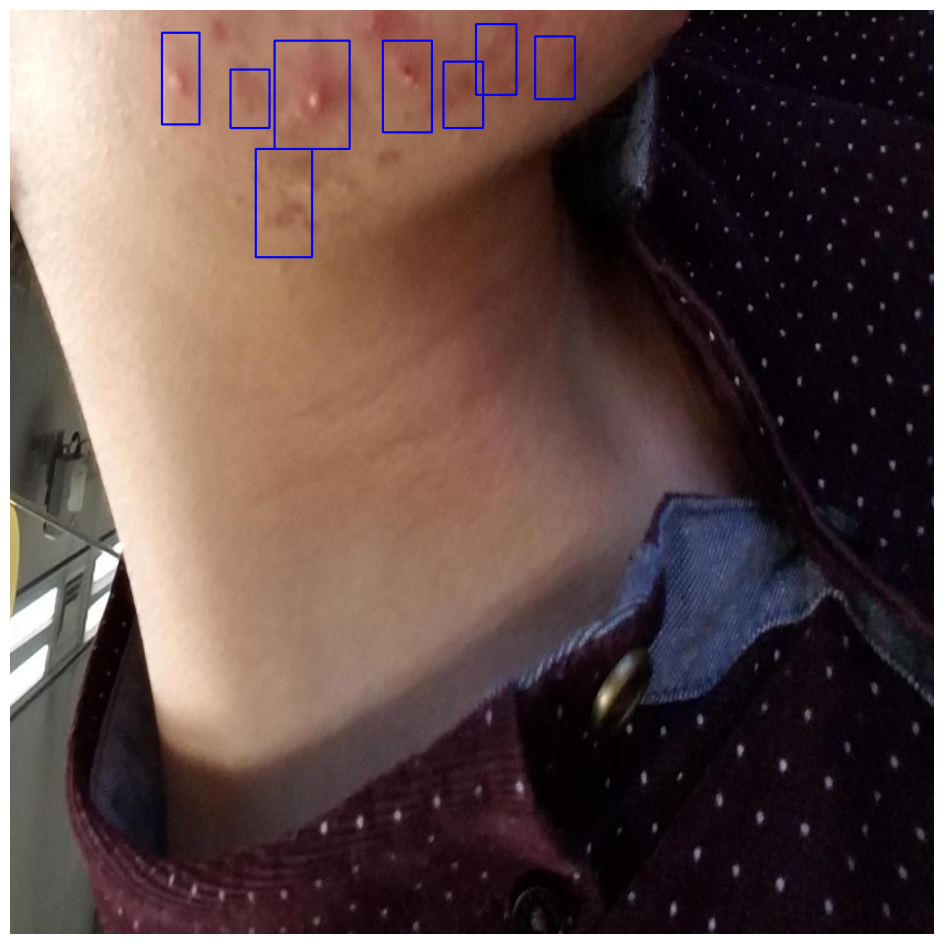

In [4]:
#num = 1001
image_filename = 'levle2_26-5.jpg'
image_name, patch_id = image_filename.split('-')[0], int(image_filename.split('-')[1].split('.')[0])
frag = df_patches[(df_patches['filename'] == image_filename) & (df_patches['patch_id'] == patch_id)]

image = Image.open(f'data/Patches/{image_filename}').convert('RGB')
img_arr = np.array(image)
H, W, C = img_arr.shape
print(H, W)
print(len(frag))
if len(frag) > 0:
    for idx, row in frag.iterrows():
        x_center, y_center, width, height = row['x_center'], row['y_center'], row['width'], row['height']
        xmin, ymin, xmax, ymax = yolo_to_bbox((x_center, y_center, width, height), img_height=H, img_width=W)
        cv.rectangle(img_arr, (int(xmin), int(ymax)), (int(xmax), int(ymin)), (0, 0, 255), 2)

plt.figure(figsize=(12, 12))
plt.axis('off')
plt.imshow(img_arr)
plt.show()

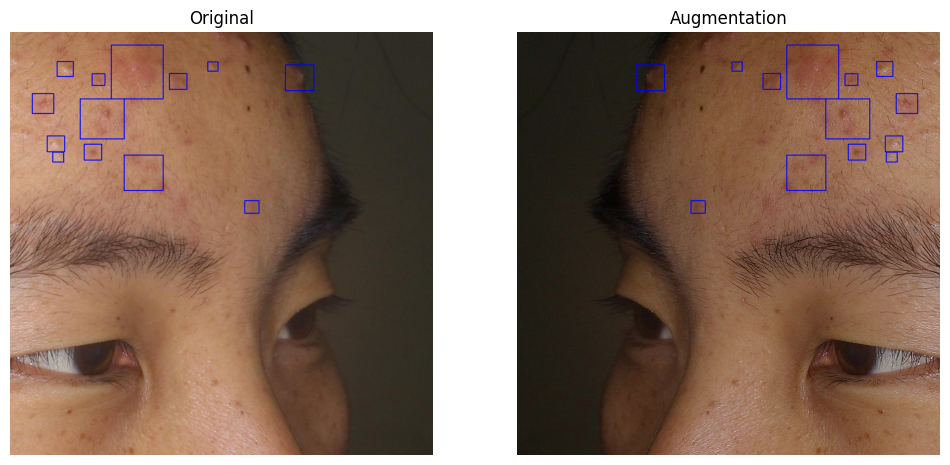

In [12]:
import albumentations as A
import torch

from src.utils.transforms import return_transforms
image_name = 'levle2_101-6.jpg'
path = f'data/Patches/{image_name}'

img = Image.open(path).convert('RGB')
img_arr = np.array(img)
img_show = np.array(img)
H, W, C = img_arr.shape

frame = df_patches[df_patches['filename'] == image_name]
transform = return_transforms()

boxes = []
labels = []
if len(frame) > 0:
    for _, row in frame.iterrows():
        x_center, y_center, width, height = row['x_center'], row['y_center'], row['width'], row['height']
        boxes.append([x_center, y_center, width, height])
        labels.append(row['class_id'])
        xmin, ymin, xmax, ymax = yolo_to_bbox((x_center, y_center, width, height), img_height=H, img_width=W)
        cv.rectangle(img_show, (int(xmin), int(ymax)), (int(xmax), int(ymin)), (0, 0, 255), 2)

#boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
#labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.tensor([], dtype=torch.int64)
#print(boxes)
#print(labels)


transformed = transform(image = img_arr, bboxes = boxes, labels = labels)

fig, (ax1, ax2) = plt.subplots(nrows = 1,ncols = 2, figsize = (12, 24))
#fig.figure(fig_size = (8, 16))
ax1.imshow(img_show)
ax1.axis('off')
ax1.set_title('Original')

img_transformed = np.copy(transformed['image'])

for item in transformed['bboxes']:
    x_center, y_center, width, height = item
    xmin, ymin, xmax, ymax = yolo_to_bbox((x_center, y_center, width, height), img_height=H, img_width=W)
    cv.rectangle(img_transformed, (int(xmin), int(ymax)), (int(xmax), int(ymin)), (0, 0, 255), 2)

ax2.imshow(img_transformed)
ax2.axis('off')
ax2.set_title('Augmentation')

plt.show()

